In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/healthcare_dataset.csv")

In [4]:

df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
df.info()


Shape: (55500, 15)

Columns:
Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

Missing Values:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 555

In [6]:

df.dtypes

,0
Name,object
Age,int64
Gender,object
Blood Type,object
Medical Condition,object
Date of Admission,object
Doctor,object
Hospital,object
Insurance Provider,object
Billing Amount,float64


In [16]:
df["Stay Duration"] = (
    df["Discharge Date"] - df["Date of Admission"]
).dt.days

df[["Date of Admission", "Discharge Date", "Stay Duration"]].head()


,Date of Admission,Discharge Date,Stay Duration
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


In [17]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])

In [18]:

Billing = df.groupby(["Medical Condition","Insurance Provider"])["Billing Amount"].sum()
Billing


Medical Condition  Insurance Provider
Arthritis          Aetna                 4.667744e+07
                   Blue Cross            4.776824e+07
                   Cigna                 4.810453e+07
                   Medicare              4.677861e+07
                   UnitedHealthcare      4.800029e+07
Asthma             Aetna                 4.497371e+07
                   Blue Cross            4.613516e+07
                   Cigna                 4.883917e+07
                   Medicare              4.722901e+07
                   UnitedHealthcare      4.828272e+07
Cancer             Aetna                 4.533568e+07
                   Blue Cross            4.538242e+07
                   Cigna                 4.768493e+07
                   Medicare              4.728065e+07
                   UnitedHealthcare      4.648417e+07
Diabetes           Aetna                 4.709108e+07
                   Blue Cross            4.802529e+07
                   Cigna                 4.855774e+07
                   Medicare              4.885277e+07
                   UnitedHealthcare      4.601285e+07
Hypertension       Aetna                 4.858130e+07
                   Blue Cross            4.658659e+07
                   Cigna                 4.527089e+07
                   Medicare              4.767472e+07
                   UnitedHealthcare      4.760715e+07
Obesity            Aetna                 4.620389e+07
                   Blue Cross            4.935658e+07
                   Cigna                 4.868209e+07
                   Medicare              4.790500e+07
                   UnitedHealthcare      4.606736e+07
Name: Billing Amount, dtype: float64

In [19]:


data = df.groupby(
    ["Medical Condition", "Insurance Provider"]
)["Billing Amount"].mean().unstack()

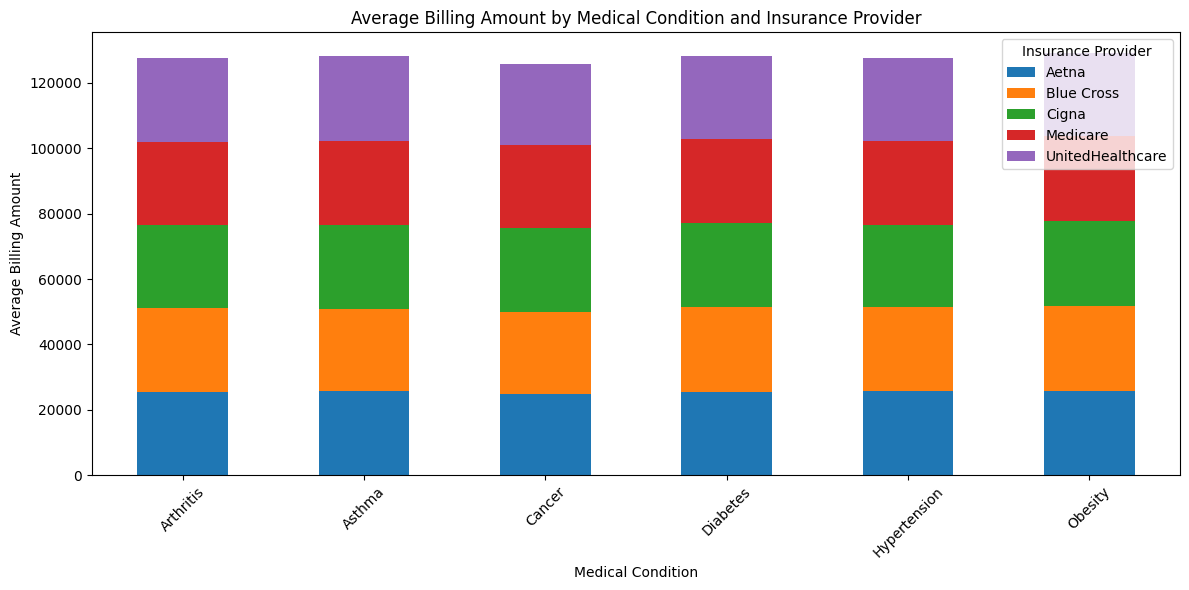

In [20]:
data.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Average Billing Amount by Medical Condition and Insurance Provider")
plt.xlabel("Medical Condition")
plt.ylabel("Average Billing Amount")
plt.xticks(rotation=45)
plt.legend(title="Insurance Provider")

plt.tight_layout()
plt.show()

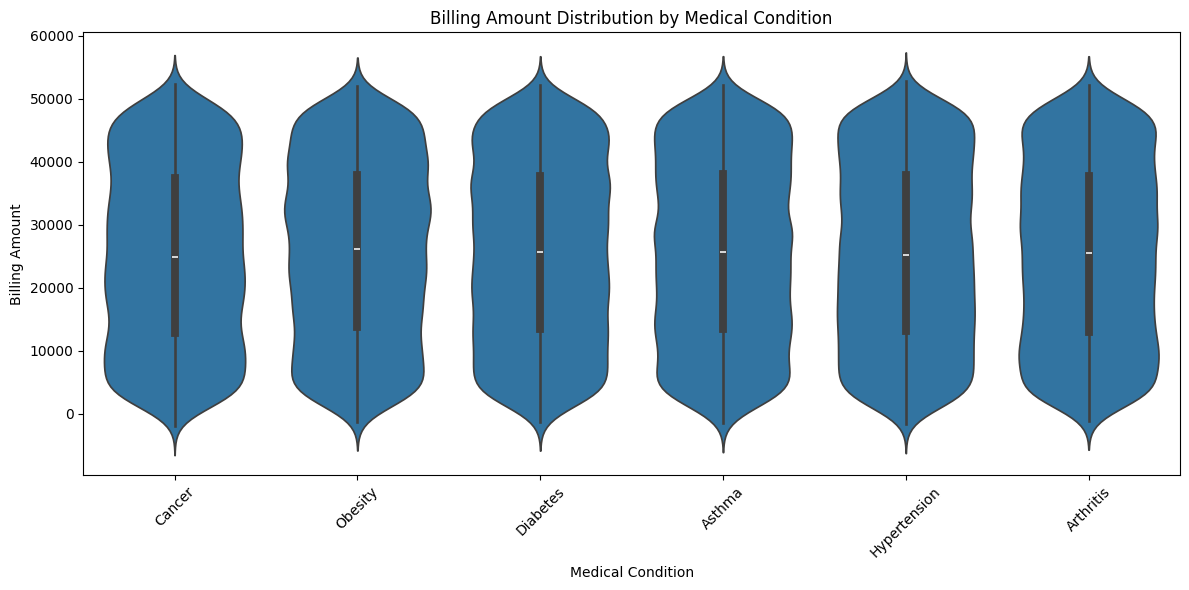

In [21]:

plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x="Medical Condition",
    y="Billing Amount"
)

plt.title("Billing Amount Distribution by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Billing Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


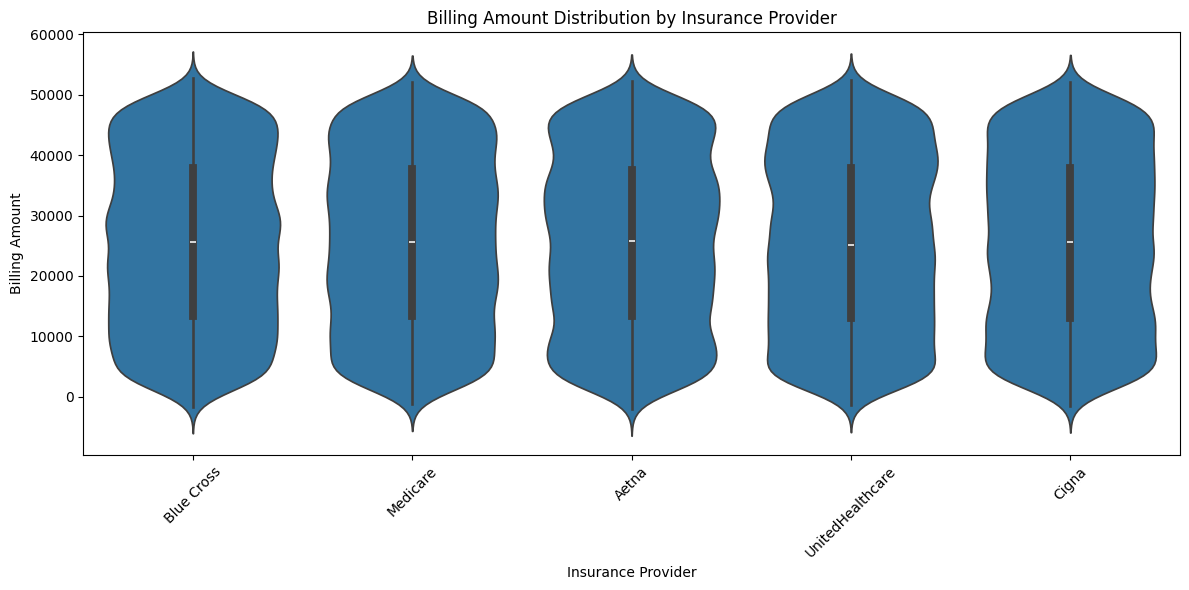

In [22]:

plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x="Insurance Provider",
    y="Billing Amount"
)

plt.title("Billing Amount Distribution by Insurance Provider")
plt.xlabel("Insurance Provider")
plt.ylabel("Billing Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

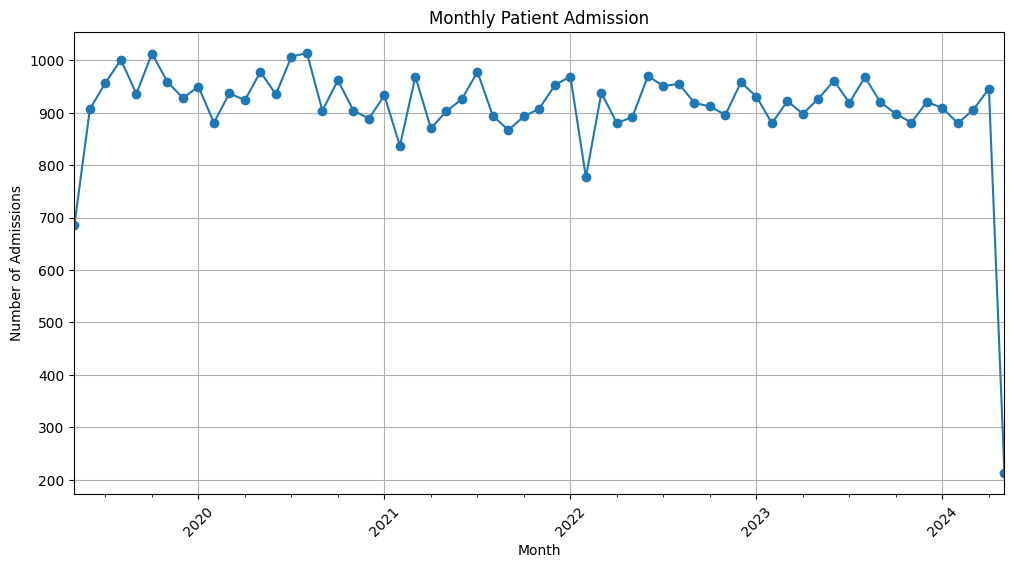

In [23]:

plt.figure(figsize=(12,6))
df['Admission_Month'] = df['Date of Admission'].dt.to_period('M')
Monthly_Admission = df.groupby('Admission_Month').size()
Monthly_Admission.plot(kind="line",marker="o")

plt.title("Monthly Patient Admission")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.grid()


In [24]:

corelation_matrix=df[["Age","Stay Duration","Billing Amount"]].corr()
corelation_matrix

,Age,Stay Duration,Billing Amount
Age,1.000000,0.008220,-0.003832
Stay Duration,0.008220,1.000000,-0.005602
Billing Amount,-0.003832,-0.005602,1.000000


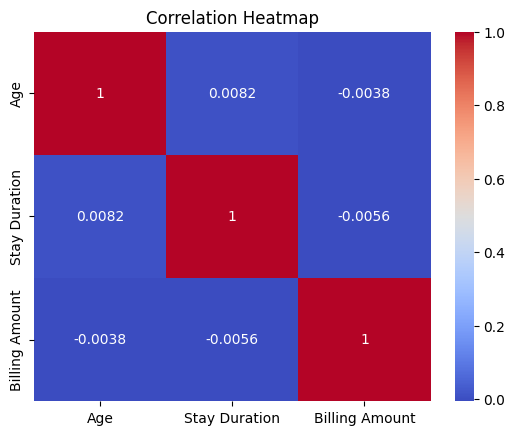

In [25]:
sns.heatmap(corelation_matrix,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

